In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import keras
from keras import backend as K
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras.callbacks import History
import tensorflow as tf
from tensorflow.keras import layers
import joblib
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt
import os

2025-07-14 12:06:49.204952: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-14 12:06:49.205023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-14 12:06:49.206245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-14 12:06:49.213931: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Import Data (scaled and sequential)

In [2]:
scaled_input_ohc_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.nc')

In [4]:
scaled_input_olr_train[:10]

array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.00696635,
        -1.57224238, -1.56264472],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.05872321,
        -1.45092595, -1.42210627],
       [-1.40209067, -0.98124057, -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494005, -2.02849984, -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.29735371,  0.27511233],
       [ 0.46322525,  0.50955927,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]])

In [5]:
sequential_input_olr_train[:10]

<xarray.DataArray (time: 10, newdim: 2662)> Size: 106kB
array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.0069664 ,
        -1.5722424 , -1.5626447 ],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.0587232 ,
        -1.450926  , -1.4221063 ],
       [-1.4020907 , -0.9812406 , -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494   , -2.0284998 , -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.2973537 ,  0.27511233],
       [ 0.46322525,  0.5095593 ,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]], dtype=float32)
Coordinates:
  * time     (time) object 80B 0282-10-01 00:00:00 ... 0100-10-01 00:00:00
    month    (time) int64 80B 10 8 1 7 2 5 1 2 10 10
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

In [6]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## Build Variational Autoencoder

In [7]:
# set random seed
keras.utils.set_random_seed(1)

In [8]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ssh
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for zonal stress
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [9]:
# define latent space (going to be 2 here)
latent_dim = 20

In [10]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(180, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(30, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(180, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(30, activation='tanh')(encoded_ohc_layer4)

# zonal stress input 
# ssh input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(180, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(30, activation='tanh')(encoded_olr_layer4)

(None, 2968)


2025-07-14 12:07:57.272825: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2662)


In [11]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [12]:
# create latent space with z_mean and z_log_var
# this will create dense layers with 2 nodes because of latent_dim 

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [13]:
# reparameterization trick 
# "we now treat random sampling as a noise term
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

In [14]:
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [15]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(30, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(180, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(30, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(180, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# zonal stress
decoded1_olr = Dense(30, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(180, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [16]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [17]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                              

In [18]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # Reconstruction loss
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # Total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [19]:
# Add the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [20]:
# Define VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0003)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [21]:
# Fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 6s 365ms/step - loss: 2.5540 - sst_loss: 0.8168 - ohc_loss: 0.7057 - olr_loss: 1.0621 - kl_loss: 0.0099 - val_loss: 2.1870 - val_sst_loss: 0.6010 - val_ohc_loss: 0.5652 - val_olr_loss: 0.9930 - val_kl_loss: 0.0131
Epoch 2/150
15/15 [==============================] - 5s 352ms/step - loss: 1.9241 - sst_loss: 0.5052 - ohc_loss: 0.5099 - olr_loss: 0.8920 - kl_loss: 0.0115 - val_loss: 1.8180 - val_sst_loss: 0.4693 - val_ohc_loss: 0.4679 - val_olr_loss: 0.8587 - val_kl_loss: 0.0130
Epoch 3/150
15/15 [==============================] - 5s 350ms/step - loss: 1.6735 - sst_loss: 0.4228 - ohc_loss: 0.4289 - olr_loss: 0.8043 - kl_loss: 0.0133 - val_loss: 1.6371 - val_sst_loss: 0.4032 - val_ohc_loss: 0.4023 - val_olr_loss: 0.8101 - val_kl_loss: 0.0140
Epoch 4/150
15/15 [==============================] - 5s 346ms/step - loss: 1.5275 - sst_loss: 0.3730 - ohc_loss: 0.3787 - olr_loss: 0.7698 - kl_loss: 0.0143 - val_loss: 1.5529 - val_sst_loss: 0.3699 

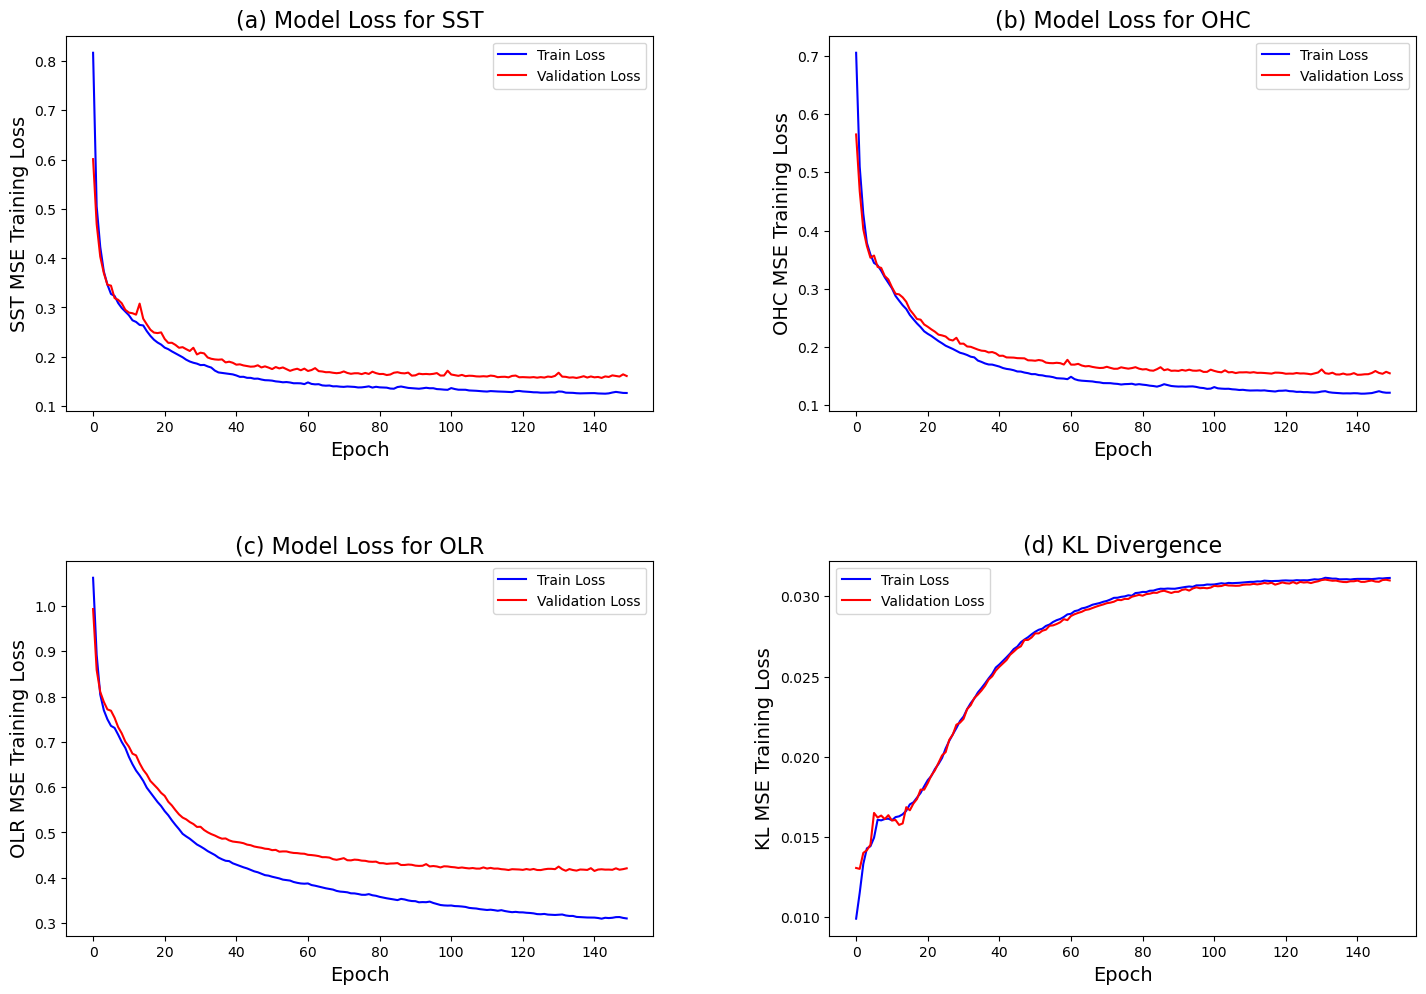

In [22]:
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.30, hspace=0.4)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot for SST Loss
axes[0].set_title('(a) Model Loss for SST', fontsize=16)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('SST MSE Training Loss', fontsize=14)
axes[0].plot(vae_model_history.history['sst_loss'], color='blue', label='Train Loss')
axes[0].plot(vae_model_history.history['val_sst_loss'], color='red', label='Validation Loss')
axes[0].legend(loc='best')

# Plot for OHC Loss
axes[1].set_title('(b) Model Loss for OHC', fontsize=16)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('OHC MSE Training Loss', fontsize=14)
axes[1].plot(vae_model_history.history['ohc_loss'], color='blue', label='Train Loss')
axes[1].plot(vae_model_history.history['val_ohc_loss'], color='red', label='Validation Loss')
axes[1].legend(loc='best')

# Plot for OLR Loss
axes[2].set_title('(c) Model Loss for OLR', fontsize=16)
axes[2].set_xlabel('Epoch', fontsize=14)
axes[2].set_ylabel('OLR MSE Training Loss', fontsize=14)
axes[2].plot(vae_model_history.history['olr_loss'], color='blue', label='Train Loss')
axes[2].plot(vae_model_history.history['val_olr_loss'], color='red', label='Validation Loss')
axes[2].legend(loc='best')

# Plot for KL Loss
axes[3].set_title('(d) KL Divergence', fontsize=16)
axes[3].set_xlabel('Epoch', fontsize=14)
axes[3].set_ylabel('KL MSE Training Loss', fontsize=14)
axes[3].plot(vae_model_history.history['kl_loss'], color='blue', label='Train Loss')
axes[3].plot(vae_model_history.history['val_kl_loss'], color='red', label='Validation Loss')
axes[3].legend(loc='best')

# fig.suptitle('Adam, 150 Epochs, 256 Batch Size, 0.3 Validation Split', fontsize=20, y=1.02)
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scholarly_paper/vae_loss_0507.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Extract latent space using sequential data

In [23]:
# Concatenate the train and test datasets along the 'time' dimension
ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time')
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time')

In [24]:
# use sort by for sequential data along time dimension
ohc_sequential = ohc_combined.sortby('time')
olr_sequential = olr_combined.sortby('time')
sst_sequential = sst_combined.sortby('time')

In [25]:
# slice train and test if needed later on
ohc_train = ohc_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
ohc_test = ohc_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
olr_train = olr_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
olr_test = olr_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
sst_train = sst_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
sst_test = sst_sequential.sel(time=slice('0401-01-01', '0500-12-01'))

In [26]:
sst_sequential

<xarray.DataArray (time: 6000, newdim: 2968)> Size: 71MB
array([[-0.46650478, -0.3197793 , -0.29813683, ..., -0.55164415,
        -0.5829566 , -0.66701674],
       [-0.17773718, -0.21565889, -0.21351056, ..., -0.23025233,
        -0.18700024, -0.21649799],
       [ 0.10382219,  0.08966852,  0.05962231, ..., -0.35251725,
        -0.27474537, -0.17154494],
       ...,
       [ 1.4205452 ,  1.400869  ,  1.4167161 , ...,  0.22103727,
         0.25323433,  0.22178286],
       [ 1.0547311 ,  1.0982207 ,  1.1158875 , ..., -0.3618258 ,
        -0.3364225 , -0.292119  ],
       [-0.14510034, -0.11480391, -0.11065638, ..., -0.519485  ,
        -0.6436    , -0.6071442 ]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [27]:
ohc_sequential

<xarray.DataArray (time: 6000, newdim: 2960)> Size: 71MB
array([[-0.06281169, -0.20906061, -0.18186705, ...,  0.62362224,
         0.83531636,  0.61176914],
       [ 0.03483214, -0.06134811, -0.01326702, ...,  0.28284457,
         0.55402124,  0.5225092 ],
       [-0.05450004, -0.07871224, -0.10955569, ...,  0.18483937,
         0.28161588,  0.22350661],
       ...,
       [ 0.8442785 ,  0.84061056,  0.7513687 , ..., -0.2521005 ,
        -0.36358503, -0.23370646],
       [ 0.88659567,  0.8248726 ,  0.7177427 , ..., -0.32499006,
        -0.5276498 , -0.35859805],
       [ 0.68769425,  0.63446355,  0.54791397, ..., -0.6282569 ,
        -0.96252984, -0.82144856]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [28]:
olr_sequential

<xarray.DataArray (time: 6000, newdim: 2662)> Size: 64MB
array([[ 0.24241254,  0.30834833,  0.22684942, ...,  0.23112747,
         0.29370552,  0.37244037],
       [-0.926759  , -0.5931658 , -0.07895295, ...,  0.30462354,
         0.35614526,  0.43503544],
       [ 1.3475112 ,  1.1852772 ,  0.91891044, ..., -0.31582242,
        -0.2003353 ,  0.01002645],
       ...,
       [ 0.10129009,  0.15584187,  0.18799162, ..., -0.90907973,
        -1.1965964 , -1.5710752 ],
       [-0.38905463, -0.17948021, -0.36370125, ...,  2.4602287 ,
         2.3406508 ,  1.9990622 ],
       [-2.331803  , -2.1585054 , -2.1295793 , ...,  0.68693286,
         0.7712001 ,  0.86353195]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

## oni

In [29]:
# check relation to enso phase
oni_e3sm = xr.open_dataset('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/oni_e3sm_0502.nc')

In [30]:
oni_e3sm['oni'].values

array([        nan, -0.5401118 , -0.42085293, ..., -2.2914636 ,
       -2.4201982 ,         nan], dtype=float32)

In [31]:
# check dataset to make sure variable were retained properly
print(oni_e3sm['enso_phase'].values[:10])
print(np.unique(oni_e3sm['season'].values))
print(oni_e3sm['month'].values)

['Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Neutral' 'Neutral']
['AMJ' 'ASO' 'DJF' 'FMA' 'JAS' 'JFM' 'JJA' 'MAM' 'MJJ' 'NDJ' 'OND' 'SON']
[ 1  2  3 ... 10 11 12]


In [32]:
enso_labels = oni_e3sm['enso_phase'].values

## latent representations

In [33]:
encoder_model = Model(inputs=[input_sst, input_ohc, input_olr],
                      outputs=[z]
                     )

In [34]:
encoder_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                            

In [35]:
keras.utils.set_random_seed(1)
latent_representations = encoder_model.predict([sst_sequential,
                                                ohc_sequential,
                                                olr_sequential]
                                              )

print(latent_representations.shape)

188/188 [==============================] - 2s 5ms/step
(6000, 20)


In [36]:
print(latent_representations.mean(),
      latent_representations.std(),
      latent_representations.min(), 
      latent_representations.max()
     )

-0.115941845 0.7986182 -3.4591534 3.171792


In [37]:
enso_labels_full = oni_e3sm['enso_phase'].values

In [38]:
len(enso_labels_full) == latent_representations.shape[0]

True

In [39]:
latent_enso_phases = enso_labels_full

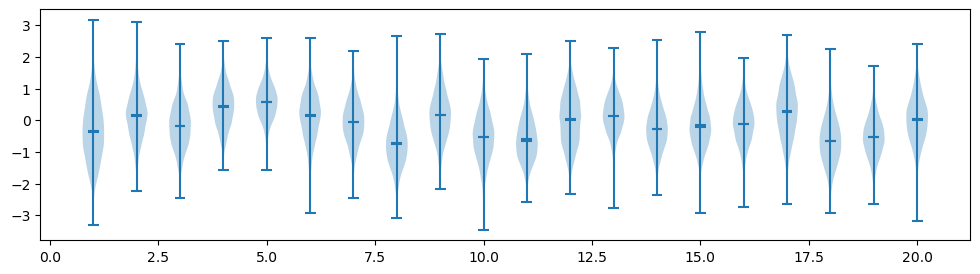

In [40]:
plt.figure(figsize=(12,3))
plt.violinplot(
    latent_representations[:,:],
    showmeans=True,
    showextrema=True,
    showmedians=True,
)
plt.show()

In [41]:
# Make a DataFrame combining both
ds_latent = pd.DataFrame(latent_representations)
ds_latent['ENSO Phase'] = enso_labels_full

# Now you can filter by phase
el_nino_events = ds_latent[ds_latent['ENSO Phase'] == 'El Niño']
la_nina_events = ds_latent[ds_latent['ENSO Phase'] == 'La Niña']
neutral_events = ds_latent[ds_latent['ENSO Phase'] == 'Neutral']

In [42]:
ds_latent

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,ENSO Phase
0,-0.171373,0.151088,1.036778,0.491472,0.443188,0.709718,-0.291277,-2.191796,0.853658,0.774097,...,-0.715828,-0.277033,-0.152253,-0.867034,-0.380100,1.204398,0.036143,-1.370845,0.529348,Neutral
1,-0.681262,-0.440878,0.317826,0.466533,0.363076,1.194626,-0.342722,-1.823882,0.635270,0.005028,...,0.074126,0.187489,0.816319,-0.767143,-0.201551,1.043479,-2.073040,-1.634411,0.763999,Neutral
2,-0.809714,0.333094,0.615899,0.232857,0.763208,0.805971,-0.449011,-1.961102,0.936449,-0.001336,...,0.249262,0.210445,0.529183,-0.907812,0.420121,0.359503,-0.351987,-1.248261,-0.050643,Neutral
3,-1.366033,-0.091314,-0.489170,-0.147440,0.384599,0.164724,-0.299356,-0.465003,0.947303,0.217690,...,0.720446,0.750483,-0.156022,-1.555034,-0.877145,0.032260,-2.193750,-1.376351,-0.170055,Neutral
4,-1.048478,0.248464,-0.601794,-0.842099,1.543813,-0.595817,-0.219612,-0.435509,0.868121,-0.556538,...,0.226838,0.831011,0.487405,-0.591896,-0.479811,-0.412583,-1.729209,-0.608300,-0.322703,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-1.017088,-1.305089,0.223985,0.232368,1.541063,1.181149,-1.153888,-1.261705,-0.805570,-0.951330,...,-1.278657,-1.174468,-1.179999,0.433732,-0.880360,0.648913,0.811779,0.781761,1.245457,Neutral
5996,-1.822763,-1.601204,0.204514,0.125368,1.824180,1.483932,-1.084182,-0.997506,-1.117894,-0.595071,...,-1.429541,-0.143665,-0.521019,0.029951,-0.654121,1.015819,1.205748,1.458520,0.741754,Neutral
5997,-2.167440,-1.514919,-0.207632,0.455958,1.089262,1.102956,-0.933025,-0.952336,-0.944370,-0.746917,...,-1.495720,-0.042200,-0.681705,-0.294884,-0.570864,0.656430,0.815853,1.399856,0.559257,La Niña
5998,-2.090098,-1.131711,0.490936,0.424978,0.883789,0.898438,-1.072017,-1.320402,-1.109559,-0.415177,...,-1.441819,-0.352641,-0.892286,-0.333832,-0.882969,1.251281,0.635624,0.437742,1.321822,La Niña


In [43]:
print(el_nino_events.shape,
      la_nina_events.shape,
      neutral_events.shape
     )

(831, 21) (819, 21) (4350, 21)


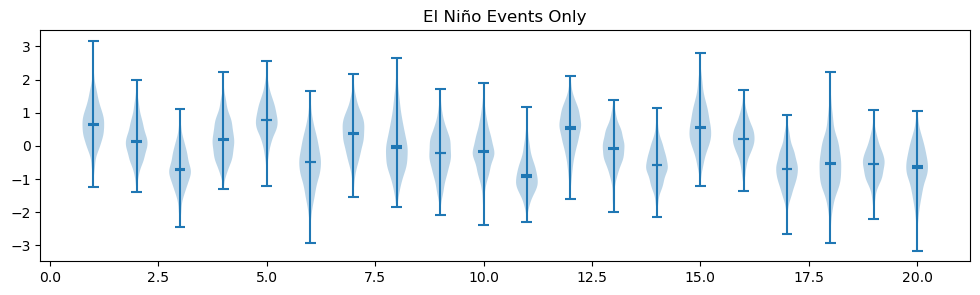

In [44]:
plt.figure(figsize=(12,3))
plt.violinplot(
    el_nino_events.iloc[:,:-1],
    showmeans=True,
    showextrema=True,
    showmedians=True,
)
plt.title('El Niño Events Only')
plt.show()

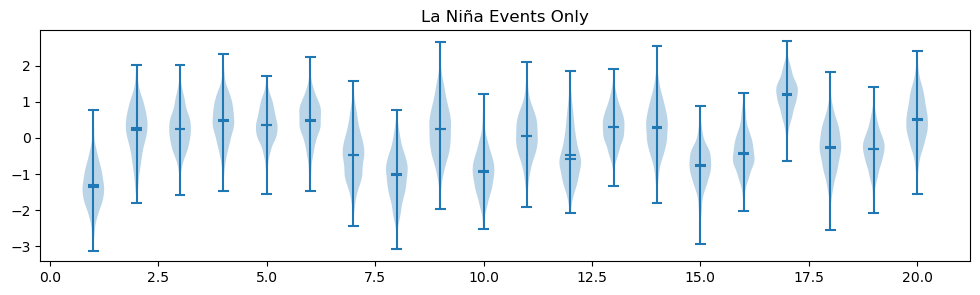

In [45]:
plt.figure(figsize=(12,3))
plt.violinplot(
    la_nina_events.iloc[:,:-1],
    showmeans=True,
    showextrema=True,
    showmedians=True,
)
plt.title('La Niña Events Only')
plt.show()

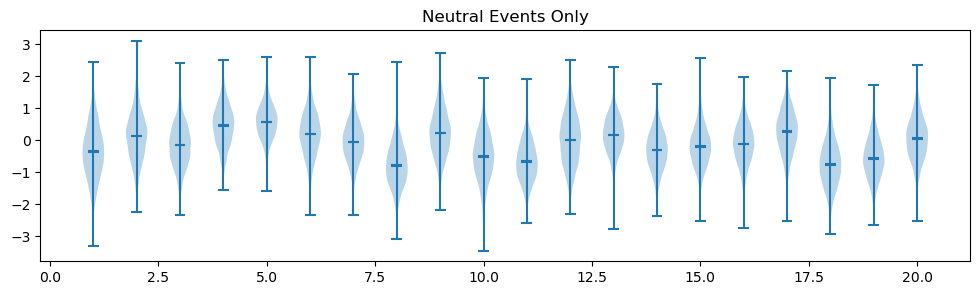

In [46]:
plt.figure(figsize=(12,3))
plt.violinplot(
    neutral_events.iloc[:,:-1],
    showmeans=True,
    showextrema=True,
    showmedians=True,
)
plt.title('Neutral Events Only')
plt.show()

## split violin plots with seaborn

In [47]:
# Combine into one dataframe
ds_combined = pd.concat([el_nino_events, la_nina_events], ignore_index=True)

# Melt to long format for seaborn
ds_melted = ds_combined.melt(id_vars='ENSO Phase', var_name='Latent Dimension', value_name='Value')

In [48]:
ds_melted

,ENSO Phase,Latent Dimension,Value
0,El Niño,0,0.818339
1,El Niño,0,1.021789
2,El Niño,0,1.401276
3,El Niño,0,1.833472
4,El Niño,0,0.892211
...,...,...,...
32995,La Niña,19,0.481513
32996,La Niña,19,0.295568
32997,La Niña,19,0.104041
32998,La Niña,19,0.559257


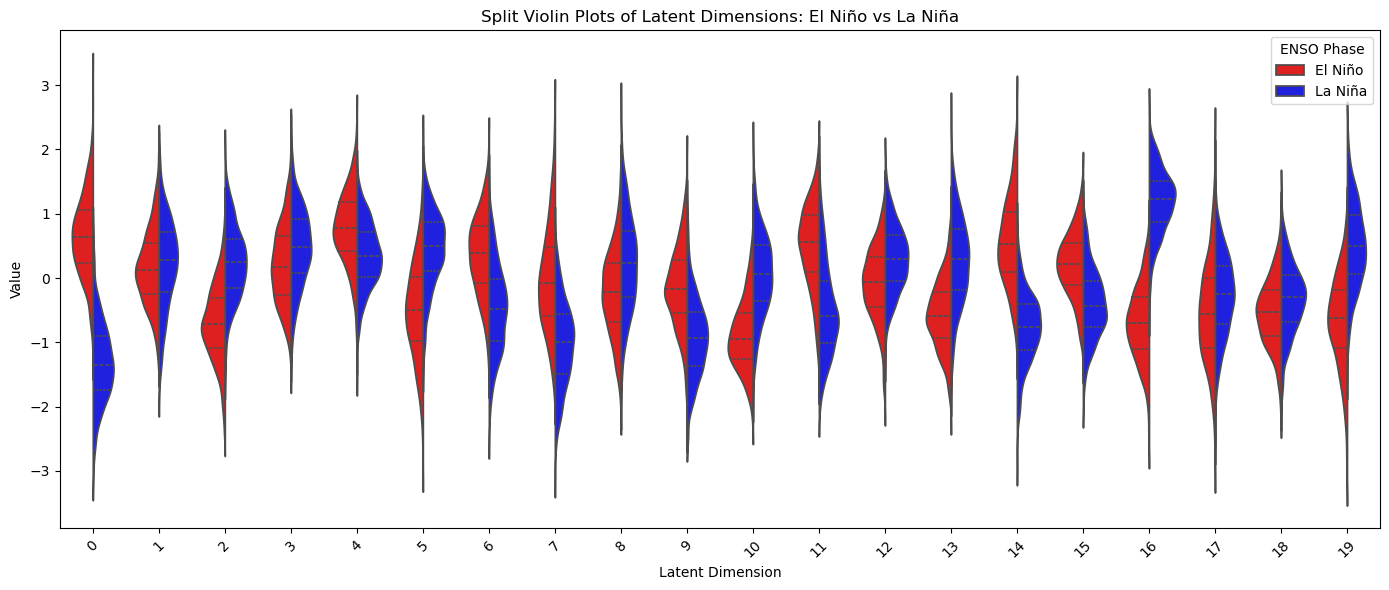

In [49]:
import seaborn as sns

# Plot split violin
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=ds_melted,
    x='Latent Dimension',
    y='Value',
    hue='ENSO Phase',
    split=True,
    palette={'El Niño': 'red', 'La Niña': 'blue'},
    inner='quartile'
)
plt.xticks(rotation=45)
plt.title('Split Violin Plots of Latent Dimensions: El Niño vs La Niña')
plt.tight_layout()
#plt.savefig('violinplots_0710.pdf')
plt.show()

## mean composites to investigate different latent dims

In [50]:
# clean up code here:

# latent representations defined above
# enso labels defined above

In [51]:
decoder_model = Model(inputs=[z],
                     outputs=[output_sst,
                              output_ohc,
                              output_olr]
                     )
decoder_model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20)]                 0         []                            
                                                                                                  
 dense_15 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                                  
 dense_20 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                                  
 dense_25 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                            

In [52]:
scaler_sst = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_sst.pkl')
scaler_ohc = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_ohc_700_0228.pkl')
scaler_olr = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_olr.pkl')

In [53]:
# indices can be loaded anytime and used for reconstruction
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')

ohc_yindx = np.load('ohc_yindx.npy')
ohc_xindx = np.load('ohc_xindx.npy')

olr_yindx = np.load('olr_yindx.npy')
olr_xindx = np.load('olr_xindx.npy')

## sst

In [70]:
def generate_all_sst_composites(latent_representations,
                                decoder_model,
                                scaler_sst,
                                sst_yindx,
                                sst_xindx, 
                                enso_labels_full,
                                output_dir='means_composites/sst_composites'):
    os.makedirs(output_dir, exist_ok=True)

    def reconstruct_grid(pred_1d, y_indx, x_indx):
        n_samples = pred_1d.shape[0]
        pred_grid = np.full((n_samples, 20, 150), np.nan)
        pred_grid[:, y_indx, x_indx] = pred_1d
        return pred_grid

    # Get ENSO phase indices once
    nino_idx = np.where(enso_labels_full == 'El Niño')[0]
    nina_idx = np.where(enso_labels_full == 'La Niña')[0]
    neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

    for ld in range(20):
        print(f"Processing LD{ld}...")

        # Step 1: Create latent copy with only the current dimension active
        #latent_copy = np.zeros_like(latent_representations)
        #latent_copy[:, ld] = latent_representations[:, ld]

        # alternative step 1: fill in latent representations inactive dimensions
        # with means instead of zeroes
        latent_copy = np.copy(latent_representations)

        # calculate the mean of dimensions except the one varied
        # remove dimension 'ld'
        inactive_dims = np.delete(latent_copy, ld, axis=1)
        mean_inactive = np.mean(inactive_dims, axis=1)

        # repeat mean for entire time series length (6000)
        latent_copy[:, np.delete(np.arange(latent_copy.shape[1]), ld)] = mean_inactive[:, None]

        # Step 2: Decode
        recon_sst, _, _ = decoder_model.predict(latent_copy)

        # Step 3: Inverse scale
        flattened_sst = recon_sst.reshape(len(recon_sst), -1)
        sst_physical = scaler_sst.inverse_transform(flattened_sst)

        # Step 4: Reconstruct grid
        sst_grid = reconstruct_grid(sst_physical, sst_yindx, sst_xindx)

        # Step 5: ENSO phase subsets
        sst_nino = sst_grid[nino_idx]
        sst_nina = sst_grid[nina_idx]

        # Step 6: Composites
        sst_nino_mean = sst_nino.mean(axis=0)
        sst_nina_mean = sst_nina.mean(axis=0)
        sst_nino_std = sst_nino.std(axis=0)
        sst_nina_std = sst_nina.std(axis=0)

        # Step 7: Plot
        fig, axs = plt.subplots(2, 2, figsize=(24, 10))
        cmap_mean = 'RdBu_r'
        cmap_std = 'viridis'

        im1 = axs[0, 0].imshow(sst_nino_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-2, vmax=2)
        axs[0, 0].set_title(f'LD{ld} SST Mean Composite - El Niño')
        cbar1 = fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)
        cbar1.set_label('°C')

        im2 = axs[0, 1].imshow(sst_nina_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-2, vmax=2)
        axs[0, 1].set_title(f'LD{ld} SST Mean Composite - La Niña')
        cbar2 = fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)
        cbar2.set_label('°C')

        im3 = axs[1, 0].imshow(sst_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-1, vmax=1)
        axs[1, 0].set_title(f'LD{ld} SST Std Dev - El Niño')
        fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

        im4 = axs[1, 1].imshow(sst_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-1, vmax=1)
        axs[1, 1].set_title(f'LD{ld} SST Std Dev - La Niña')
        fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

        for ax in axs.flat:
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')

        plt.tight_layout()

        # Step 8: Save figure
        save_path = os.path.join(output_dir, f'ld{ld}_sst_composites.pdf')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"Saved to {save_path}")

In [71]:
generate_all_sst_composites(
    latent_representations=latent_representations,
    decoder_model=decoder_model,
    scaler_sst=scaler_sst,
    sst_yindx=sst_yindx,
    sst_xindx=sst_xindx,
    enso_labels_full=enso_labels_full,
    output_dir='means_composites/sst_composites'  # or any path you want
)

Processing LD0...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/sst_composites/ld0_sst_composites.pdf
Processing LD1...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/sst_composites/ld1_sst_composites.pdf
Processing LD2...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/sst_composites/ld2_sst_composites.pdf
Processing LD3...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/sst_composites/ld3_sst_composites.pdf
Processing LD4...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/sst_composites/ld4_sst_composites.pdf
Processing LD5...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/sst_composites/ld5_sst_composites.pdf
Processing LD6...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/sst_composites/ld6_sst_composites.pdf
Processing LD7...
188/188 [==============

## ohc

In [72]:
def generate_all_ohc_composites(latent_representations,
                                decoder_model,
                                scaler_ohc,
                                ohc_yindx,
                                ohc_xindx, 
                                enso_labels_full,
                                output_dir='means_composites/ohc_composites'):
    os.makedirs(output_dir, exist_ok=True)

    def reconstruct_grid(pred_1d, y_indx, x_indx):
        n_samples = pred_1d.shape[0]
        pred_grid = np.full((n_samples, 20, 150), np.nan)
        pred_grid[:, y_indx, x_indx] = pred_1d
        return pred_grid

    # Get ENSO phase indices once
    nino_idx = np.where(enso_labels_full == 'El Niño')[0]
    nina_idx = np.where(enso_labels_full == 'La Niña')[0]
    neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

    for ld in range(20):
        print(f"Processing LD{ld}...")

        # Step 1: Create latent copy with only the current dimension active
        #latent_copy = np.zeros_like(latent_representations)
        #latent_copy[:, ld] = latent_representations[:, ld]

        # alternative step 1: fill in latent representations inactive dimensions
        # with means instead of zeroes
        latent_copy = np.copy(latent_representations)

        # calculate the mean of dimensions except the one varied
        # remove dimension 'ld'
        inactive_dims = np.delete(latent_copy, ld, axis=1)
        mean_inactive = np.mean(inactive_dims, axis=1)

        # repeat mean for entire time series length (6000)
        latent_copy[:, np.delete(np.arange(latent_copy.shape[1]), ld)] = mean_inactive[:, None]

        # Step 2: Decode
        recon_sst, recon_ohc, recon_olr = decoder_model.predict(latent_copy)

        # Step 3: Inverse scale
        flattened_ohc = recon_ohc.reshape(len(recon_ohc), -1)
        ohc_physical = scaler_ohc.inverse_transform(flattened_ohc)

        # Step 4: Reconstruct grid
        ohc_grid = reconstruct_grid(ohc_physical, ohc_yindx, ohc_xindx)

        # Step 5: ENSO phase subsets
        ohc_nino = ohc_grid[nino_idx]
        ohc_nina = ohc_grid[nina_idx]

        # Step 6: Composites
        ohc_nino_mean = ohc_nino.mean(axis=0)
        ohc_nina_mean = ohc_nina.mean(axis=0)
        ohc_nino_std = ohc_nino.std(axis=0)
        ohc_nina_std = ohc_nina.std(axis=0)

        # Step 7: Plot
        fig, axs = plt.subplots(2, 2, figsize=(24, 10))
        cmap_mean_ohc = 'RdYlBu_r'
        cmap_std = 'viridis'

        im1 = axs[0, 0].imshow(ohc_nino_mean, cmap=cmap_mean_ohc, origin='lower', aspect='auto', vmin=-1.5e9, vmax=1.5e9)
        axs[0, 0].set_title(f'LD{ld} OHC Mean Composite - El Niño')
        cbar1 = fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)
        cbar1.set_label('10⁹ J/m²')

        im2 = axs[0, 1].imshow(ohc_nina_mean, cmap=cmap_mean_ohc, origin='lower', aspect='auto', vmin=-1.5e9, vmax=1.5e9)
        axs[0, 1].set_title(f'LD{ld} OHC Mean Composite - La Niña')
        cbar2 = fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)
        cbar2.set_label('10⁹ J/m²')

        im3 = axs[1, 0].imshow(ohc_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-.5e9, vmax=1e9)
        axs[1, 0].set_title(f'LD{ld} OHC Std Dev - El Niño')
        fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

        im4 = axs[1, 1].imshow(ohc_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-.5e9, vmax=1e9)
        axs[1, 1].set_title(f'LD{ld} OHC Std Dev - La Niña')
        fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

        for ax in axs.flat:
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')

        plt.tight_layout()

        # Step 8: Save figure
        save_path = os.path.join(output_dir, f'ld{ld}_ohc_composites.pdf')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"Saved to {save_path}")

In [73]:
generate_all_ohc_composites(
    latent_representations=latent_representations,
    decoder_model=decoder_model,
    scaler_ohc=scaler_ohc,
    ohc_yindx=ohc_yindx,
    ohc_xindx=ohc_xindx,
    enso_labels_full=enso_labels_full,
    output_dir='means_composites/ohc_composites'  # or any path you want
)

Processing LD0...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/ohc_composites/ld0_ohc_composites.pdf
Processing LD1...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/ohc_composites/ld1_ohc_composites.pdf
Processing LD2...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/ohc_composites/ld2_ohc_composites.pdf
Processing LD3...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/ohc_composites/ld3_ohc_composites.pdf
Processing LD4...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/ohc_composites/ld4_ohc_composites.pdf
Processing LD5...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/ohc_composites/ld5_ohc_composites.pdf
Processing LD6...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/ohc_composites/ld6_ohc_composites.pdf
Processing LD7...
188/188 [==============

## olr

In [74]:
def generate_all_olr_composites(latent_representations,
                                decoder_model,
                                scaler_olr,
                                olr_yindx,
                                olr_xindx, 
                                enso_labels_full,
                                output_dir='means_composites/olr_composites'):
    os.makedirs(output_dir, exist_ok=True)

    def reconstruct_grid_olr(pred_1d, y_indx, x_indx):
        n_samples = pred_1d.shape[0]
        pred_grid = np.full((n_samples, 22, 121), np.nan)
        pred_grid[:, y_indx, x_indx] = pred_1d
        return pred_grid

    # Get ENSO phase indices once
    nino_idx = np.where(enso_labels_full == 'El Niño')[0]
    nina_idx = np.where(enso_labels_full == 'La Niña')[0]
    neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

    for ld in range(20):
        print(f"Processing LD{ld}...")

        # Step 1: Create latent copy with only the current dimension active
        #latent_copy = np.zeros_like(latent_representations)
        #latent_copy[:, ld] = latent_representations[:, ld]

        # alternative step 1: fill in latent representations inactive dimensions
        # with means instead of zeroes
        latent_copy = np.copy(latent_representations)

        # calculate the mean of dimensions except the one varied
        # remove dimension 'ld'
        inactive_dims = np.delete(latent_copy, ld, axis=1)
        mean_inactive = np.mean(inactive_dims, axis=1)

        # repeat mean for entire time series length (6000)
        latent_copy[:, np.delete(np.arange(latent_copy.shape[1]), ld)] = mean_inactive[:, None]

        # Step 2: Decode
        recon_sst, recon_ohc, recon_olr = decoder_model.predict(latent_copy)

        # Step 3: Inverse scale
        flattened_olr = recon_olr.reshape(len(recon_olr), -1)
        olr_physical = scaler_olr.inverse_transform(flattened_olr)

        # Step 4: Reconstruct grid
        olr_grid = reconstruct_grid_olr(olr_physical, olr_yindx, olr_xindx)

        # Step 5: ENSO phase subsets
        olr_nino = olr_grid[nino_idx]
        olr_nina = olr_grid[nina_idx]

        # Step 6: Composites
        olr_nino_mean = olr_nino.mean(axis=0)
        olr_nina_mean = olr_nina.mean(axis=0)
        olr_nino_std = olr_nino.std(axis=0)
        olr_nina_std = olr_nina.std(axis=0)

        # Step 7: Plot
        fig, axs = plt.subplots(2, 2, figsize=(24, 10))
        cmap_mean_olr = 'BrBG_r'
        cmap_std = 'viridis'

        im1 = axs[0, 0].imshow(olr_nino_mean, cmap=cmap_mean_olr, origin='lower', aspect='auto', vmin = -30, vmax = 30)
        axs[0, 0].set_title(f'LD{ld} OLR Mean Composite - El Niño')
        cbar1 = fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)
        cbar1.set_label('W/m²')

        im2 = axs[0, 1].imshow(olr_nina_mean, cmap=cmap_mean_olr, origin='lower', aspect='auto', vmin = -30, vmax = 30)
        axs[0, 1].set_title(f'LD{ld} OLR Mean Composite - La Niña')
        cbar2 = fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)
        cbar2.set_label('W/m²')

        im3 = axs[1, 0].imshow(olr_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin = -2, vmax = 12)
        axs[1, 0].set_title(f'LD{ld} OLR Std Dev - El Niño')
        fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

        im4 = axs[1, 1].imshow(olr_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin = -2, vmax = 12)
        axs[1, 1].set_title(f'LD{ld} OLR Std Dev - La Niña')
        fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

        for ax in axs.flat:
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')

        plt.tight_layout()

        # Step 8: Save figure
        save_path = os.path.join(output_dir, f'ld{ld}_olr_composites.pdf')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"Saved to {save_path}")

In [75]:
generate_all_olr_composites(
    latent_representations=latent_representations,
    decoder_model=decoder_model,
    scaler_olr=scaler_olr,
    olr_yindx=olr_yindx,
    olr_xindx=olr_xindx,
    enso_labels_full=enso_labels_full,
    output_dir='means_composites/olr_composites'  # or any path you want
)

Processing LD0...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/olr_composites/ld0_olr_composites.pdf
Processing LD1...
188/188 [==============================] - 1s 3ms/step
Saved to means_composites/olr_composites/ld1_olr_composites.pdf
Processing LD2...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/olr_composites/ld2_olr_composites.pdf
Processing LD3...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/olr_composites/ld3_olr_composites.pdf
Processing LD4...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/olr_composites/ld4_olr_composites.pdf
Processing LD5...
188/188 [==============================] - 1s 7ms/step
Saved to means_composites/olr_composites/ld5_olr_composites.pdf
Processing LD6...
188/188 [==============================] - 1s 4ms/step
Saved to means_composites/olr_composites/ld6_olr_composites.pdf
Processing LD7...
188/188 [==============

## saliency maps test

In [89]:
def smoothgrad_sst_saliency(encoder_model,
                            input_sst,
                            input_ohc,
                            input_olr,
                            latent_dim,
                            n_samples=20,
                            noise_std=0.01):
    saliency_stack = []

    for _ in range(n_samples):
        sst_noisy = input_sst + tf.random.normal(input_sst.shape, stddev=noise_std)

        with tf.GradientTape() as tape:
            tape.watch(sst_noisy)
            z = encoder_model([sst_noisy, input_ohc, input_olr])
            target = z[:, latent_dim]

        grads = tape.gradient(target, sst_noisy)
        saliency_stack.append(np.abs(grads.numpy()[0]))

    return np.mean(saliency_stack, axis=0)

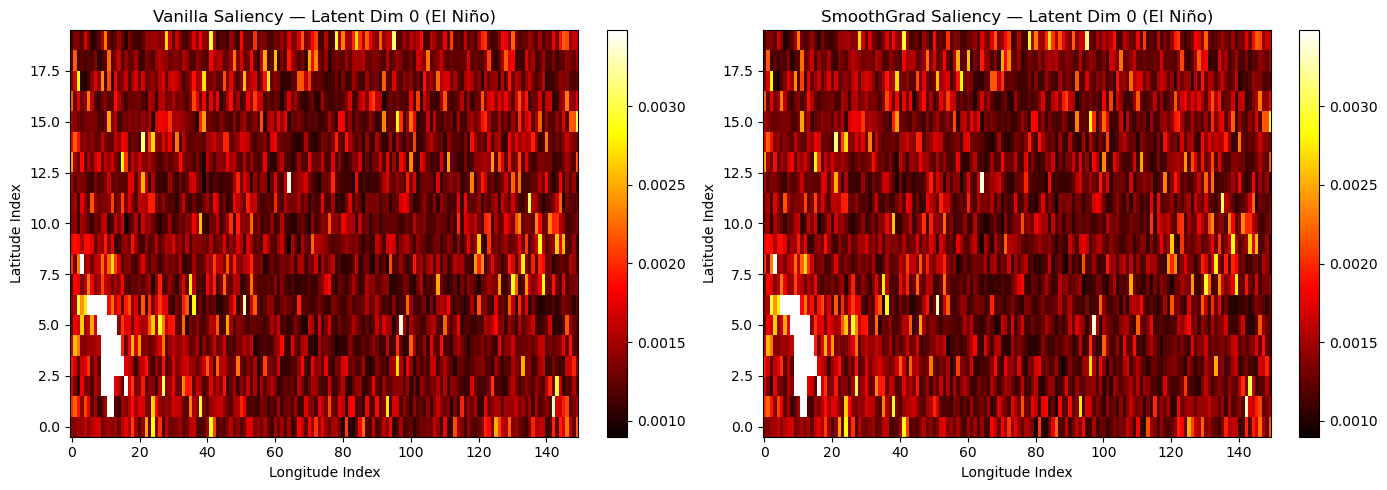

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Choose latent dimension to analyze
latent_dim = 0

# Get El Niño indices
nino_idx = np.where(enso_labels_full == 'El Niño')[0]

# Store saliency values
vanilla_saliency_list = []
smooth_saliency_list = []

for i in nino_idx:
    # Prepare input tensors
    sst_tf = tf.convert_to_tensor(sst_sequential[i:i+1], dtype=tf.float32)
    ohc_tf = tf.convert_to_tensor(ohc_sequential[i:i+1], dtype=tf.float32)
    olr_tf = tf.convert_to_tensor(olr_sequential[i:i+1], dtype=tf.float32)

    # --- Vanilla saliency ---
    with tf.GradientTape() as tape:
        tape.watch(sst_tf)
        z = encoder_model([sst_tf, ohc_tf, olr_tf])
        target = z[:, latent_dim]
    grads = tape.gradient(target, sst_tf)
    vanilla_saliency = np.abs(grads.numpy()[0])
    vanilla_saliency_list.append(vanilla_saliency)

    # --- SmoothGrad saliency ---
    smooth_saliency = smoothgrad_sst_saliency(encoder_model,
                                              sst_tf,
                                              ohc_tf,
                                              olr_tf,
                                              latent_dim)
    smooth_saliency_list.append(smooth_saliency)

# Stack and average
vanilla_avg = np.mean(np.stack(vanilla_saliency_list), axis=0)
smooth_avg = np.mean(np.stack(smooth_saliency_list), axis=0)

# Reconstruct to (20, 150) grid
vanilla_grid = np.full((20, 150), np.nan)
smooth_grid = np.full((20, 150), np.nan)
vanilla_grid[sst_yindx, sst_xindx] = vanilla_avg
smooth_grid[sst_yindx, sst_xindx] = smooth_avg

# --- Plot side by side ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

im0 = axs[0].imshow(vanilla_grid, cmap='hot', origin='lower', aspect='auto')
axs[0].set_title(f'Vanilla Saliency — Latent Dim {latent_dim} (El Niño)')
fig.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(smooth_grid, cmap='hot', origin='lower', aspect='auto')
axs[1].set_title(f'SmoothGrad Saliency — Latent Dim {latent_dim} (El Niño)')
fig.colorbar(im1, ax=axs[1], fraction=0.046)

for ax in axs:
    ax.set_xlabel("Longitude Index")
    ax.set_ylabel("Latitude Index")

plt.tight_layout()
#plt.savefig(f"saliency_ld{latent_dim}_comparison.pdf", dpi=300)
plt.show()

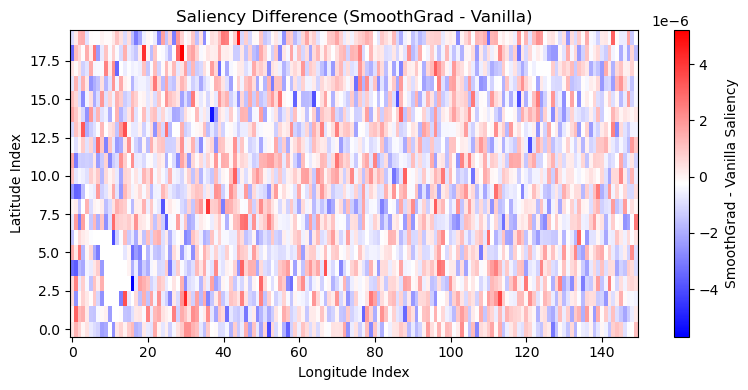

In [91]:
diff = smooth_grid - vanilla_grid

plt.figure(figsize=(8, 4))
plt.imshow(diff, cmap='bwr', origin='lower', aspect='auto')
plt.colorbar(label='SmoothGrad - Vanilla Saliency')
plt.title('Saliency Difference (SmoothGrad - Vanilla)')
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.tight_layout()
plt.show()

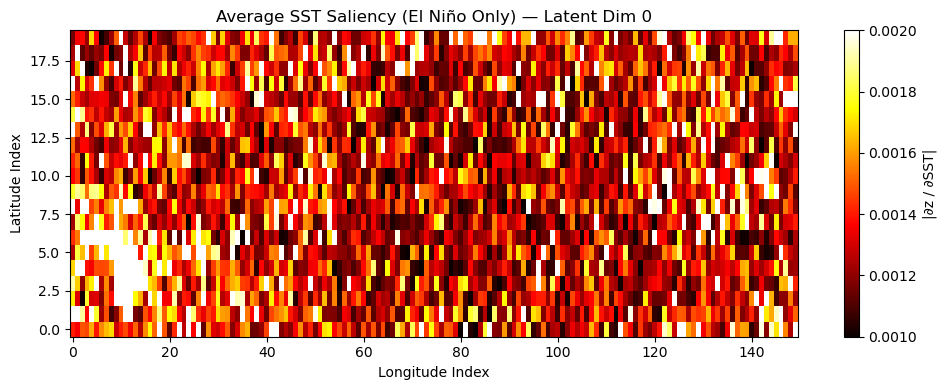

In [94]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Choose latent dimension
latent_dim = 0

# Get indices for El Niño events
nino_idx = np.where(enso_labels_full == 'El Niño')[0]

# Store saliency values for each El Niño sample
saliency_list = []

for i in nino_idx:
    sst_input = tf.convert_to_tensor(sst_sequential[i:i+1], dtype=tf.float32)
    ohc_input = tf.convert_to_tensor(ohc_sequential[i:i+1], dtype=tf.float32)
    olr_input = tf.convert_to_tensor(olr_sequential[i:i+1], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(sst_input)
        z_output = encoder_model([sst_input, ohc_input, olr_input])
        target_output = z_output[:, latent_dim]  # shape: (1,)

    grads = tape.gradient(target_output, sst_input)
    saliency = np.abs(grads.numpy()[0])  # shape: (flat_sst_dim,)
    saliency_list.append(saliency)

# Stack and average saliency across El Niño samples
saliency_mean = np.mean(np.stack(saliency_list), axis=0)

# Reconstruct 2D saliency grid
saliency_grid = np.full((20, 150), np.nan)
saliency_grid[sst_yindx, sst_xindx] = saliency_mean

# Plot
plt.figure(figsize=(10, 4))
plt.imshow(saliency_grid, cmap='hot', origin='lower', aspect='auto', vmin=0.001, vmax=0.002)
plt.title(f'Average SST Saliency (El Niño Only) — Latent Dim {latent_dim}')
plt.colorbar(label='|∂z / ∂SST|')
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.tight_layout()
plt.show()

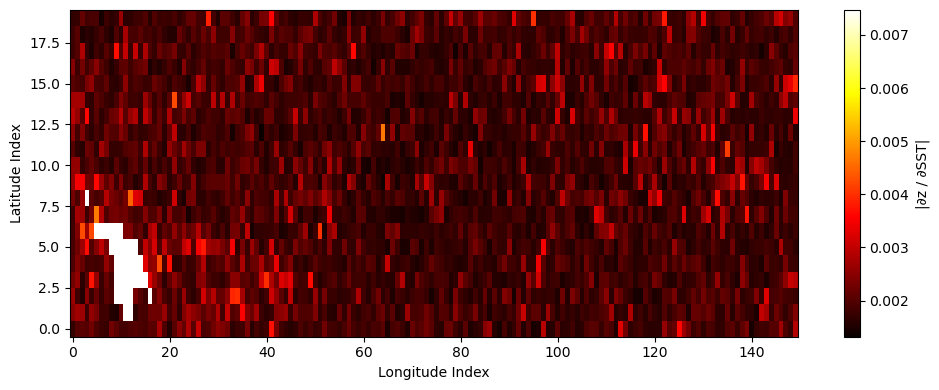

In [86]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Choose latent dimension to analyze
latent_dim = 0

# Create empty list to store gradients
saliency_list = []

# Loop over all samples
for i in range(1000):
    sst_input = tf.convert_to_tensor(sst_sequential[i:i+1], dtype=tf.float32)
    ohc_input = tf.convert_to_tensor(ohc_sequential[i:i+1], dtype=tf.float32)
    olr_input = tf.convert_to_tensor(olr_sequential[i:i+1], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(sst_input)
        z_output = encoder_model([sst_input, ohc_input, olr_input])  # shape: (1, 20)
        target_output = z_output[:, latent_dim]  # scalar for this sample

    grads = tape.gradient(target_output, sst_input)
    saliency = np.abs(grads.numpy()[0])  # shape: (n_features,)
    saliency_list.append(saliency)

# Stack and average: shape (6000, n_features) → (n_features,)
saliency_mean = np.mean(np.stack(saliency_list), axis=0)

# Reconstruct onto 2D SST grid
saliency_grid = np.full((20, 150), np.nan)
saliency_grid[sst_yindx, sst_xindx] = saliency_mean

# Plot
plt.figure(figsize=(10, 4))
plt.imshow(saliency_grid, cmap='hot', origin='lower', aspect='auto')
#plt.title(f'Average SST Saliency for Latent Dimension {latent_dim} (all 6000 samples)')
plt.colorbar(label='|∂z / ∂SST|')
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.tight_layout()
plt.show()

In [77]:
def generate_all_sst_saliency_maps(encoder_model,
                                   sst_sequential,
                                   ohc_sequential,
                                   olr_sequential,
                                   sst_yindx,
                                   sst_xindx,
                                   enso_labels_full,
                                   output_dir='saliency_maps/sst'):
    os.makedirs(output_dir, exist_ok=True)

    def reconstruct_grid(pred_1d, y_indx, x_indx):
        n_samples = pred_1d.shape[0]
        pred_grid = np.full((n_samples, 20, 150), np.nan)
        pred_grid[:, y_indx, x_indx] = pred_1d
        return pred_grid

    nino_idx = np.where(enso_labels_full == 'El Niño')[0]
    nina_idx = np.where(enso_labels_full == 'La Niña')[0]

    for ld in range(20):
        print(f"Generating saliency for LD{ld}...")

        grads_list = []

        # Loop through all samples (or a subset for speed)
        for i in range(len(sst_sequential)):
            sst_input = tf.convert_to_tensor(sst_sequential[i:i+1], dtype=tf.float32)
            ohc_input = tf.convert_to_tensor(ohc_sequential[i:i+1], dtype=tf.float32)
            olr_input = tf.convert_to_tensor(olr_sequential[i:i+1], dtype=tf.float32)

            with tf.GradientTape() as tape:
                tape.watch(sst_input)
                z_output = encoder_model([sst_input, ohc_input, olr_input])
                ld_output = z_output[:, ld]

            grads = tape.gradient(ld_output, sst_input)
            grads_list.append(np.abs(grads.numpy()[0]))  # shape: (6000,)

        grads_array = np.array(grads_list)  # shape: (6000, n_features)
        saliency_grid = reconstruct_grid(grads_array, sst_yindx, sst_xindx)  # shape: (6000, 20, 150)

        # Subset by ENSO phase
        saliency_nino = saliency_grid[nino_idx]
        saliency_nina = saliency_grid[nina_idx]

        # Composite saliency
        saliency_nino_mean = saliency_nino.mean(axis=0)
        saliency_nina_mean = saliency_nina.mean(axis=0)

        # Plotting
        for data, phase in zip([saliency_nino_mean, saliency_nina_mean], ['nino', 'nina']):
            plt.figure(figsize=(10, 4))
            im = plt.imshow(data, cmap='hot', origin='lower', aspect='auto')
            plt.colorbar(im, fraction=0.025)
            plt.title(f'SST Saliency for LD{ld} - {phase.capitalize()}')
            plt.xlabel('Longitude Index')
            plt.ylabel('Latitude Index')
            plt.tight_layout()
            plt.savefig(f"{output_dir}/LD{ld}_saliency_{phase}.pdf", dpi=300)
            plt.close()

In [79]:
generate_all_sst_saliency_maps(
    encoder_model=encoder_model,                     # your trained encoder
    sst_sequential=sst_sequential,             # your 6000xN SST input array
    ohc_sequential=ohc_sequential,             # your 6000xN OHC input array
    olr_sequential=olr_sequential,             # your 6000xN OLR input array
    sst_yindx=sst_yindx,                       # list of lat indices where SST is valid
    sst_xindx=sst_xindx,                       # list of lon indices where SST is valid
    enso_labels_full=enso_labels_full,         # array of 6000 ENSO labels
    output_dir='saliency_maps/sst'             # optional, where PDFs will be saved
)

## latent representations test

In [64]:
ld = 0

# Step 1: Create latent copy with mean values for inactive dimensions
latent_copy = np.copy(latent_representations)  # Start with a copy of the original latent space

# Calculate the mean of all latent dimensions except the one you're varying (latent dimension `ld`)
inactive_dims = np.delete(latent_copy, ld, axis=1)  # Remove the dimension `ld`
mean_inactive = np.mean(inactive_dims, axis=1)  # Mean across the remaining latent dims

# Repeat the mean for the entire timeseries and assign it to the inactive dimensions
latent_copy[:, np.delete(np.arange(latent_copy.shape[1]), ld)] = mean_inactive[:, None]

# Now, `latent_copy` has only `latent_representations[:, ld]` active, and all other dims set to their mean

In [65]:
latent_copy

array([[-0.19719967, -0.03013563, -0.03013563, ..., -0.03013563,
        -0.03013563, -0.03013563],
       [-0.9432886 , -0.10027676, -0.10027676, ..., -0.10027676,
        -0.10027676, -0.10027676],
       [-0.68305415,  0.01015186,  0.01015186, ...,  0.01015186,
         0.01015186,  0.01015186],
       ...,
       [-2.2903    , -0.10623318, -0.10623318, ..., -0.10623318,
        -0.10623318, -0.10623318],
       [-2.116374  , -0.06276743, -0.06276743, ..., -0.06276743,
        -0.06276743, -0.06276743],
       [-1.6332979 , -0.06622264, -0.06622264, ..., -0.06622264,
        -0.06622264, -0.06622264]], dtype=float32)

## SST/OHC/OLR Single Image Tests

In [78]:
# indices can be loaded anytime and used for reconstruction
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d#.values
    
    # return predictions on original 2d grid
    return pred_grid

In [79]:
# import scaler to get physical ohc values
scaler_sst = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_sst.pkl')

# Step 1: Undo the scaling (inverse transformation)
flattened_sst = reconld0_sst.reshape(len(reconld0_sst), -1)  # Flatten the data for inverse scaling
sst_physical = scaler_sst.inverse_transform(flattened_sst)

print(reconld0_sst.shape,
     sst_physical.shape
     )

(6000, 2968) (6000, 2968)


In [80]:
sst_grid = reconstruct_grid(sst_physical, sst_yindx, sst_xindx)
print(sst_grid.shape)

(6000, 20, 150)


In [81]:
# index enso phase YAY
# Get indices
nino_idx = np.where(enso_labels_full == 'El Niño')[0]
nina_idx = np.where(enso_labels_full == 'La Niña')[0]
neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

# Subset SST grid
sst_nino = sst_grid[nino_idx]     # shape: (N, 20, 150)
sst_nina = sst_grid[nina_idx]
sst_neutral = sst_grid[neutral_idx]

# Now take spatial mean
sst_nino_mean = sst_nino.mean(axis=0)  # shape: (20, 150)
sst_nina_mean = sst_nina.mean(axis=0)

# standard deviation
sst_nino_std = sst_nino.std(axis=0)
sst_nina_std = sst_nina.std(axis=0)

In [82]:
print(sst_nino.shape,
      sst_nino_mean.shape,
      sst_nino_std.shape
     )
print(sst_nina.shape,
      sst_nina_mean.shape,
      sst_nina_std.shape
     )
print(sst_neutral.shape
     )

(831, 20, 150) (20, 150) (20, 150)
(819, 20, 150) (20, 150) (20, 150)
(4350, 20, 150)


In [219]:
# Step 4: Plotting function
def plot_field(data, title, cmap='RdBu_r', vmin=None, vmax=None):
    plt.figure(figsize=(12, 4))
    im = plt.imshow(data, cmap=cmap, origin='lower', aspect='auto',
                    vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.025)
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

# Optional: consistent color scale
#vmin_mean = min(sst_nino_mean.min(), sst_nina_mean.min())
#vmax_mean = max(sst_nino_mean.max(), sst_nina_mean.max())

#vmin_std = min(sst_nino_std.min(), sst_nina_std.min())
#vmax_std = max(sst_nino_std.max(), sst_nina_std.max())

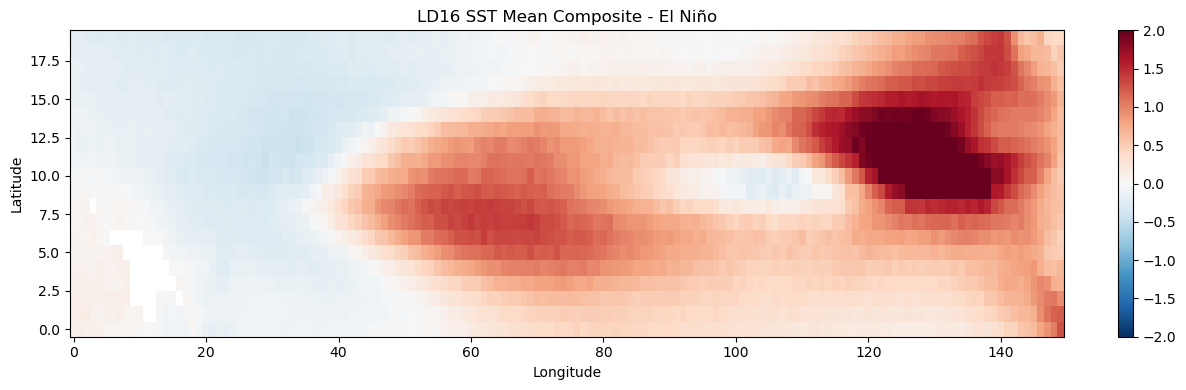

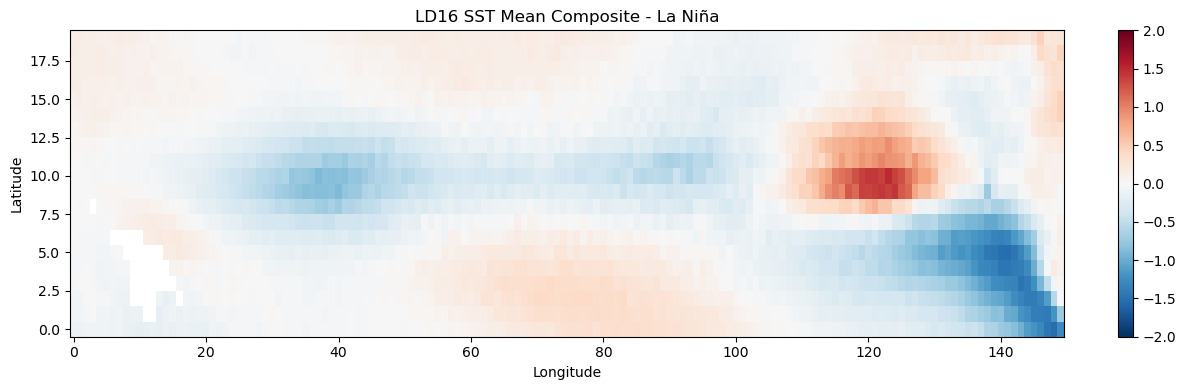

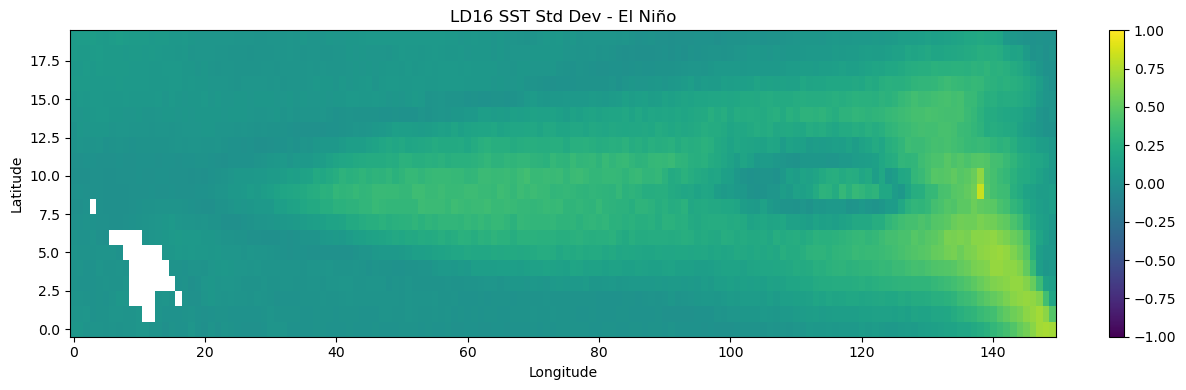

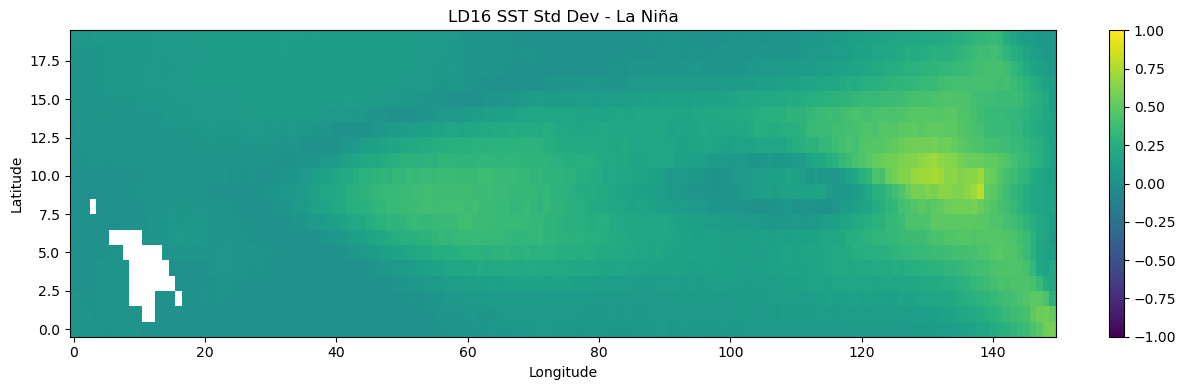

<Figure size 640x480 with 0 Axes>

In [223]:
# Step 5: Create plots
plot_field(sst_nino_mean, 'LD16 SST Mean Composite - El Niño', vmin=-2, vmax=2)
plot_field(sst_nina_mean, 'LD16 SST Mean Composite - La Niña', vmin=-2, vmax=2)

plot_field(sst_nino_std, 'LD16 SST Std Dev - El Niño', cmap='viridis', vmin=-1, vmax=1)
plot_field(sst_nina_std, 'LD16 SST Std Dev - La Niña', cmap='viridis', vmin=-1, vmax=1)

plt.show()
plt.savefig('ld16_sstcomposite_0710.pdf')
plt.show()

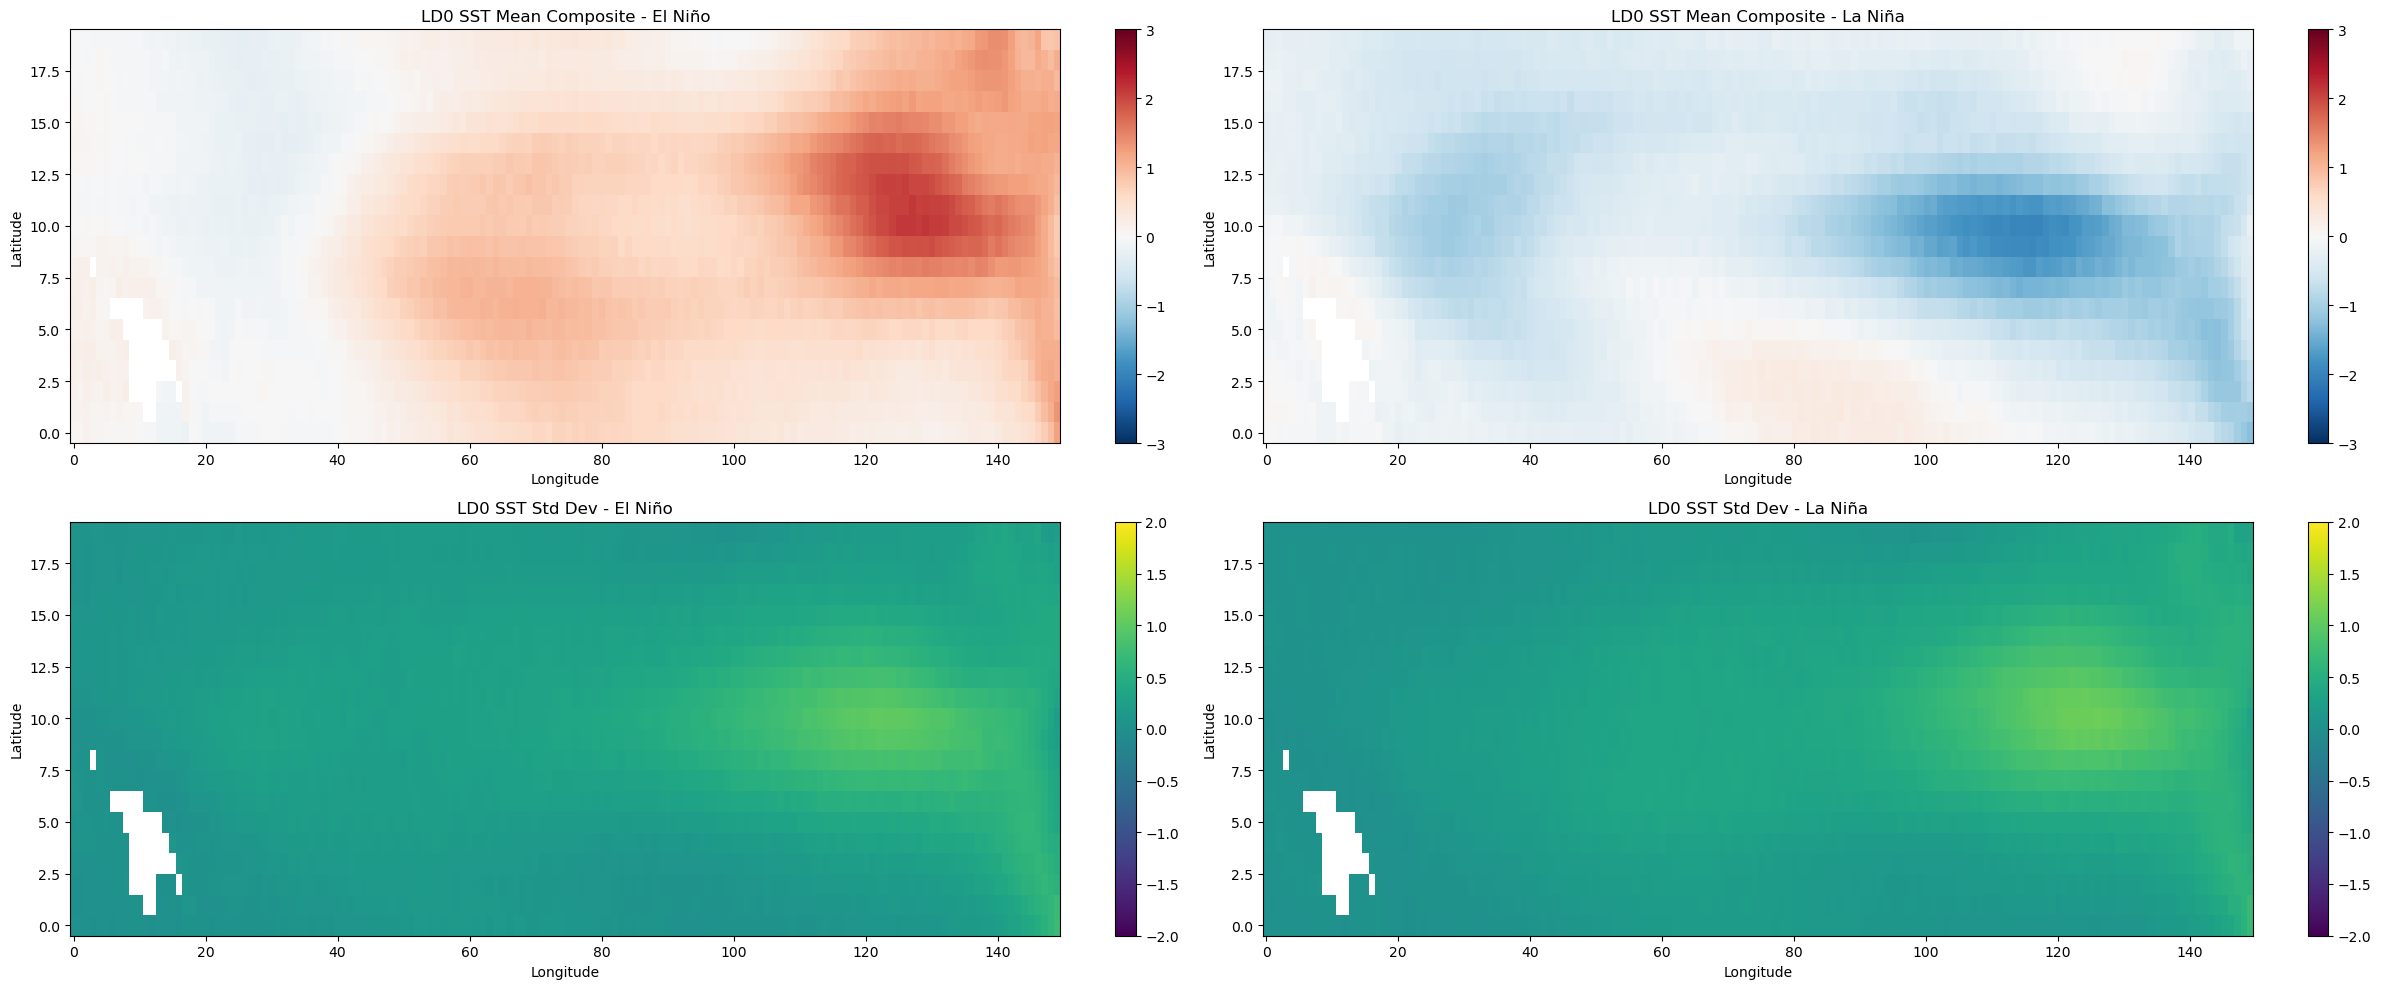

In [83]:
import matplotlib.pyplot as plt

# Create one figure with 4 subplots (2x2)
fig, axs = plt.subplots(2, 2, figsize=(24, 10))
cmap_mean = 'RdBu_r'
cmap_std = 'viridis'

# Mean Composite - El Niño
im1 = axs[0, 0].imshow(sst_nino_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-3, vmax=3)
axs[0, 0].set_title('LD0 SST Mean Composite - El Niño')
fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)

# Mean Composite - La Niña
im2 = axs[0, 1].imshow(sst_nina_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-3, vmax=3)
axs[0, 1].set_title('LD0 SST Mean Composite - La Niña')
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)

# Std Dev - El Niño
im3 = axs[1, 0].imshow(sst_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-2, vmax=2)
axs[1, 0].set_title('LD0 SST Std Dev - El Niño')
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

# Std Dev - La Niña
im4 = axs[1, 1].imshow(sst_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-2, vmax=2)
axs[1, 1].set_title('LD0 SST Std Dev - La Niña')
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

# Adjust layout and save
for ax in axs.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
#plt.savefig('ld0_sst_composites_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

## ohc test and set variables

In [75]:
# indices can be loaded anytime and used for reconstruction
ohc_yindx = np.load('ohc_yindx.npy')
ohc_xindx = np.load('ohc_xindx.npy')

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d#.values
    
    # return predictions on original 2d grid
    return pred_grid

In [77]:
# import scaler to get physical ohc values
scaler_ohc = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_ohc_700_0228.pkl')

# Step 1: Undo the scaling (inverse transformation)
flattened_ohc = reconld0_ohc.reshape(len(reconld0_ohc), -1)  # Flatten the data for inverse scaling
ohc_physical = scaler_ohc.inverse_transform(flattened_ohc)

print(reconld0_ohc.shape,
     ohc_physical.shape
     )

(6000, 2960) (6000, 2960)


In [86]:
ohc_grid = reconstruct_grid(ohc_physical, ohc_yindx, ohc_xindx)
print(ohc_grid.shape)

(6000, 20, 150)


In [87]:
# index enso phase YAY
# Get indices
nino_idx = np.where(enso_labels_full == 'El Niño')[0]
nina_idx = np.where(enso_labels_full == 'La Niña')[0]
neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

# Subset OHC grid
ohc_nino = ohc_grid[nino_idx]     # shape: (N, 20, 150)
ohc_nina = ohc_grid[nina_idx]
ohc_neutral = ohc_grid[neutral_idx]

# Now take spatial mean
ohc_nino_mean = ohc_nino.mean(axis=0)  # shape: (20, 150)
ohc_nina_mean = ohc_nina.mean(axis=0)

# standard deviation
ohc_nino_std = ohc_nino.std(axis=0)
ohc_nina_std = ohc_nina.std(axis=0)

In [88]:
print(ohc_nino.shape,
      ohc_nino_mean.shape,
      ohc_nino_std.shape
     )
print(ohc_nina.shape,
      ohc_nina_mean.shape,
      ohc_nina_std.shape
     )
print(ohc_neutral.shape
     )

(831, 20, 150) (20, 150) (20, 150)
(819, 20, 150) (20, 150) (20, 150)
(4350, 20, 150)


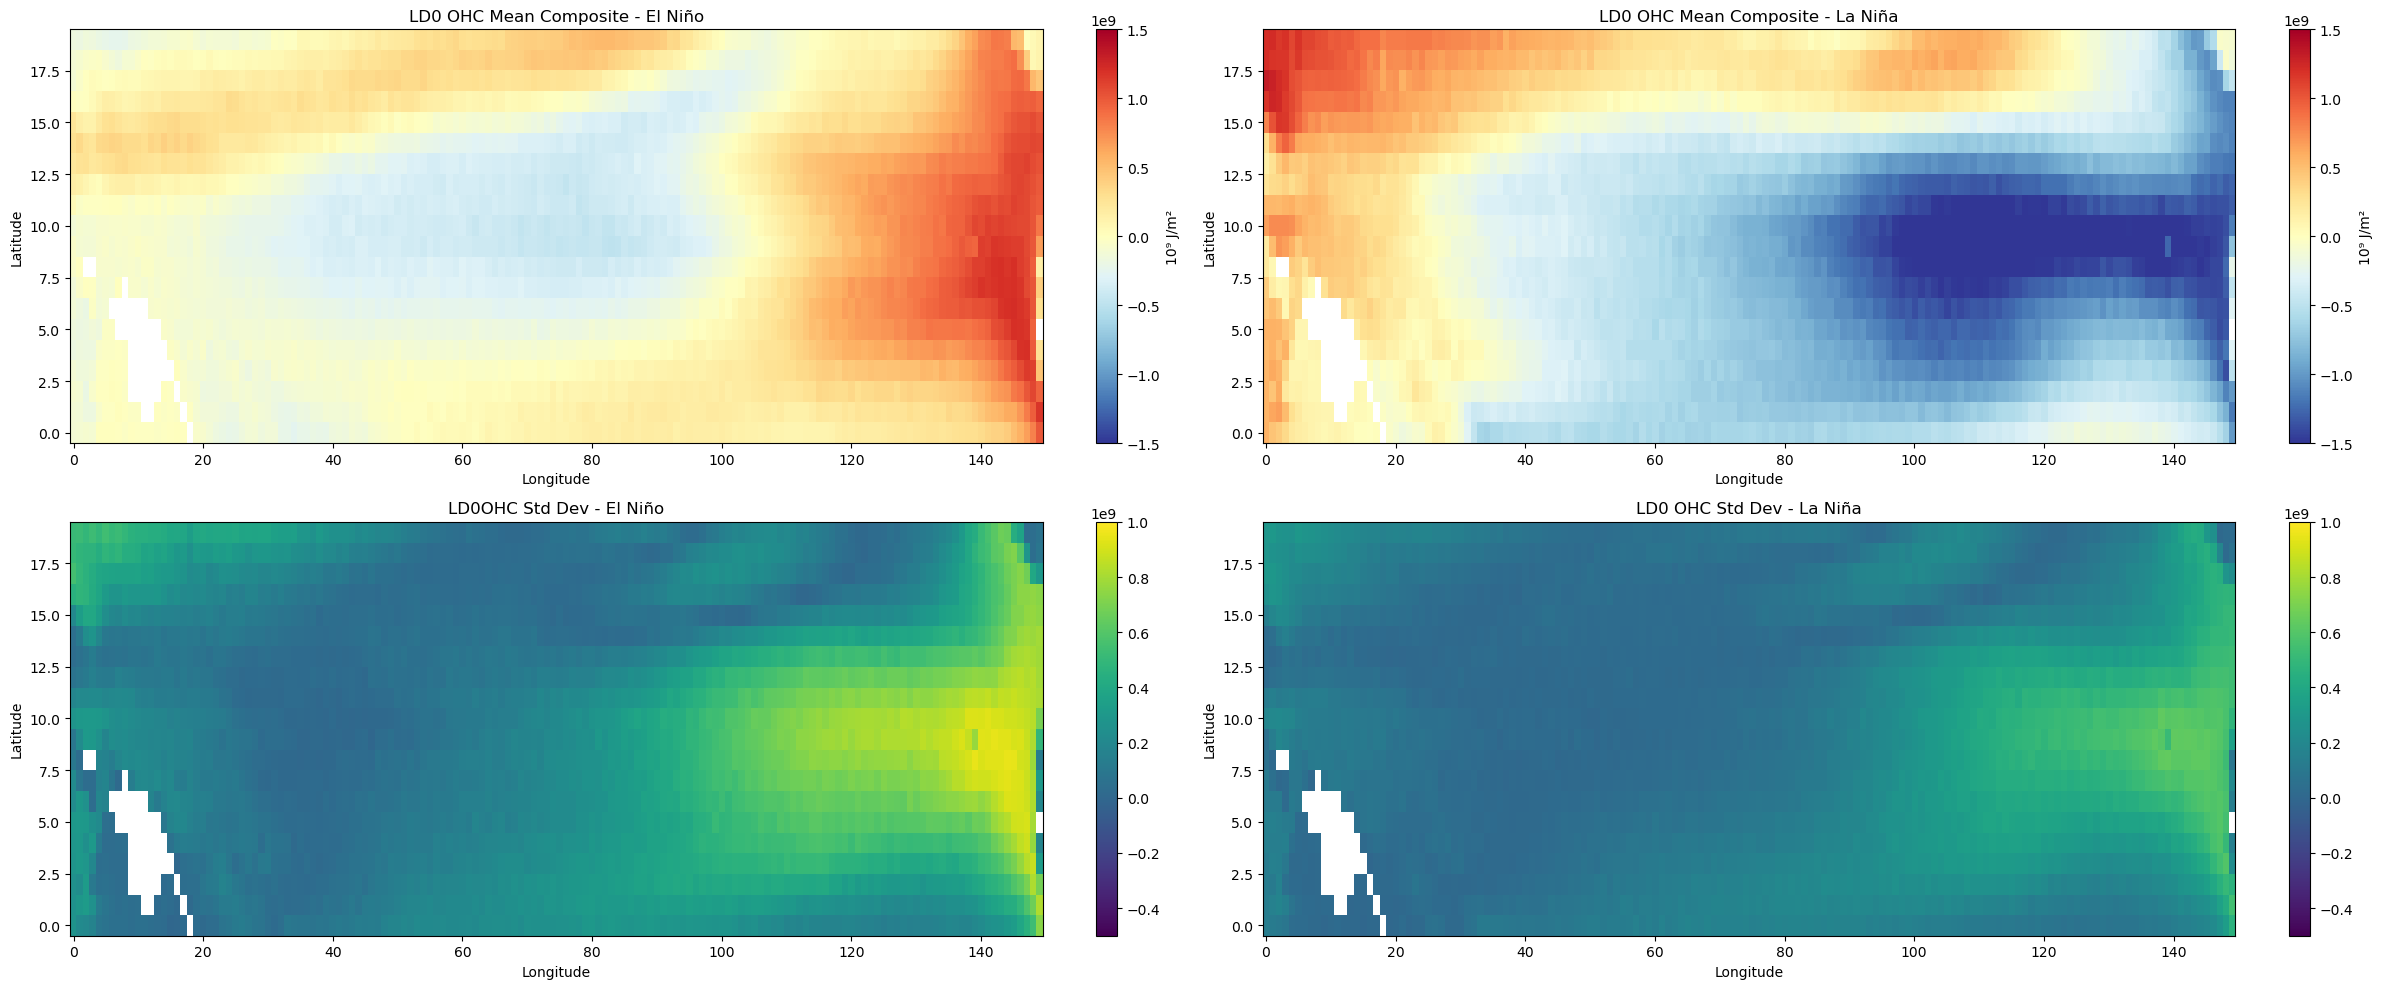

In [113]:
# Create one figure with 4 subplots (2x2)
fig, axs = plt.subplots(2, 2, figsize=(24, 10))
cmap_mean_ohc = 'RdYlBu_r'
cmap_std = 'viridis'

# Mean Composite - El Niño
im1 = axs[0, 0].imshow(ohc_nino_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-1.5e9, vmax=1.5e9)
axs[0, 0].set_title('LD0 OHC Mean Composite - El Niño')
cbar1 = fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)
cbar1.set_label('10⁹ J/m²')

# Mean Composite - La Niña
im2 = axs[0, 1].imshow(ohc_nina_mean, cmap=cmap_mean, origin='lower', aspect='auto', vmin=-1.5e9, vmax=1.5e9)
axs[0, 1].set_title('LD0 OHC Mean Composite - La Niña')
cbar2 = fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)
cbar2.set_label('10⁹ J/m²')

# Std Dev - El Niño
im3 = axs[1, 0].imshow(ohc_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-.5e9, vmax=1e9)
axs[1, 0].set_title('LD0OHC Std Dev - El Niño')
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

# Std Dev - La Niña
im4 = axs[1, 1].imshow(ohc_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin=-.5e9, vmax=1e9)
axs[1, 1].set_title('LD0 OHC Std Dev - La Niña')
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

# Adjust layout and save
for ax in axs.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
#plt.savefig('ld0_sst_composites_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

## olr test and set variables

In [123]:
# indices can be loaded anytime and used for reconstruction
olr_yindx = np.load('olr_yindx.npy')
olr_xindx = np.load('olr_xindx.npy')

def reconstruct_grid_olr(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (22)
        x_indx (numpy array): longitude indices for grid (121)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 22, 121), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d#.values
    
    # return predictions on original 2d grid
    return pred_grid

In [124]:
# import scaler to get physical ohc values
scaler_olr = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scaler_olr.pkl')

# Step 1: Undo the scaling (inverse transformation)
flattened_olr = reconld0_olr.reshape(len(reconld0_olr), -1)  # Flatten the data for inverse scaling
olr_physical = scaler_olr.inverse_transform(flattened_olr)

print(reconld0_olr.shape,
     olr_physical.shape
     )

(6000, 2662) (6000, 2662)


In [125]:
olr_grid = reconstruct_grid_olr(olr_physical, olr_yindx, olr_xindx)
print(olr_grid.shape)

(6000, 22, 121)


In [126]:
# index enso phase YAY
# Get indices
nino_idx = np.where(enso_labels_full == 'El Niño')[0]
nina_idx = np.where(enso_labels_full == 'La Niña')[0]
neutral_idx = np.where(enso_labels_full == 'Neutral')[0]

# Subset OLR grid
olr_nino = olr_grid[nino_idx]     # shape: (N, 20, 150)
olr_nina = olr_grid[nina_idx]
olr_neutral = olr_grid[neutral_idx]

# Now take spatial mean
olr_nino_mean = olr_nino.mean(axis=0)  # shape: (20, 150)
olr_nina_mean = olr_nina.mean(axis=0)

# standard deviation
olr_nino_std = olr_nino.std(axis=0)
olr_nina_std = olr_nina.std(axis=0)

In [127]:
print(olr_nino.shape,
      olr_nino_mean.shape,
      olr_nino_std.shape
     )
print(olr_nina.shape,
      olr_nina_mean.shape,
      olr_nina_std.shape
     )
print(olr_neutral.shape
     )

(831, 22, 121) (22, 121) (22, 121)
(819, 22, 121) (22, 121) (22, 121)
(4350, 22, 121)


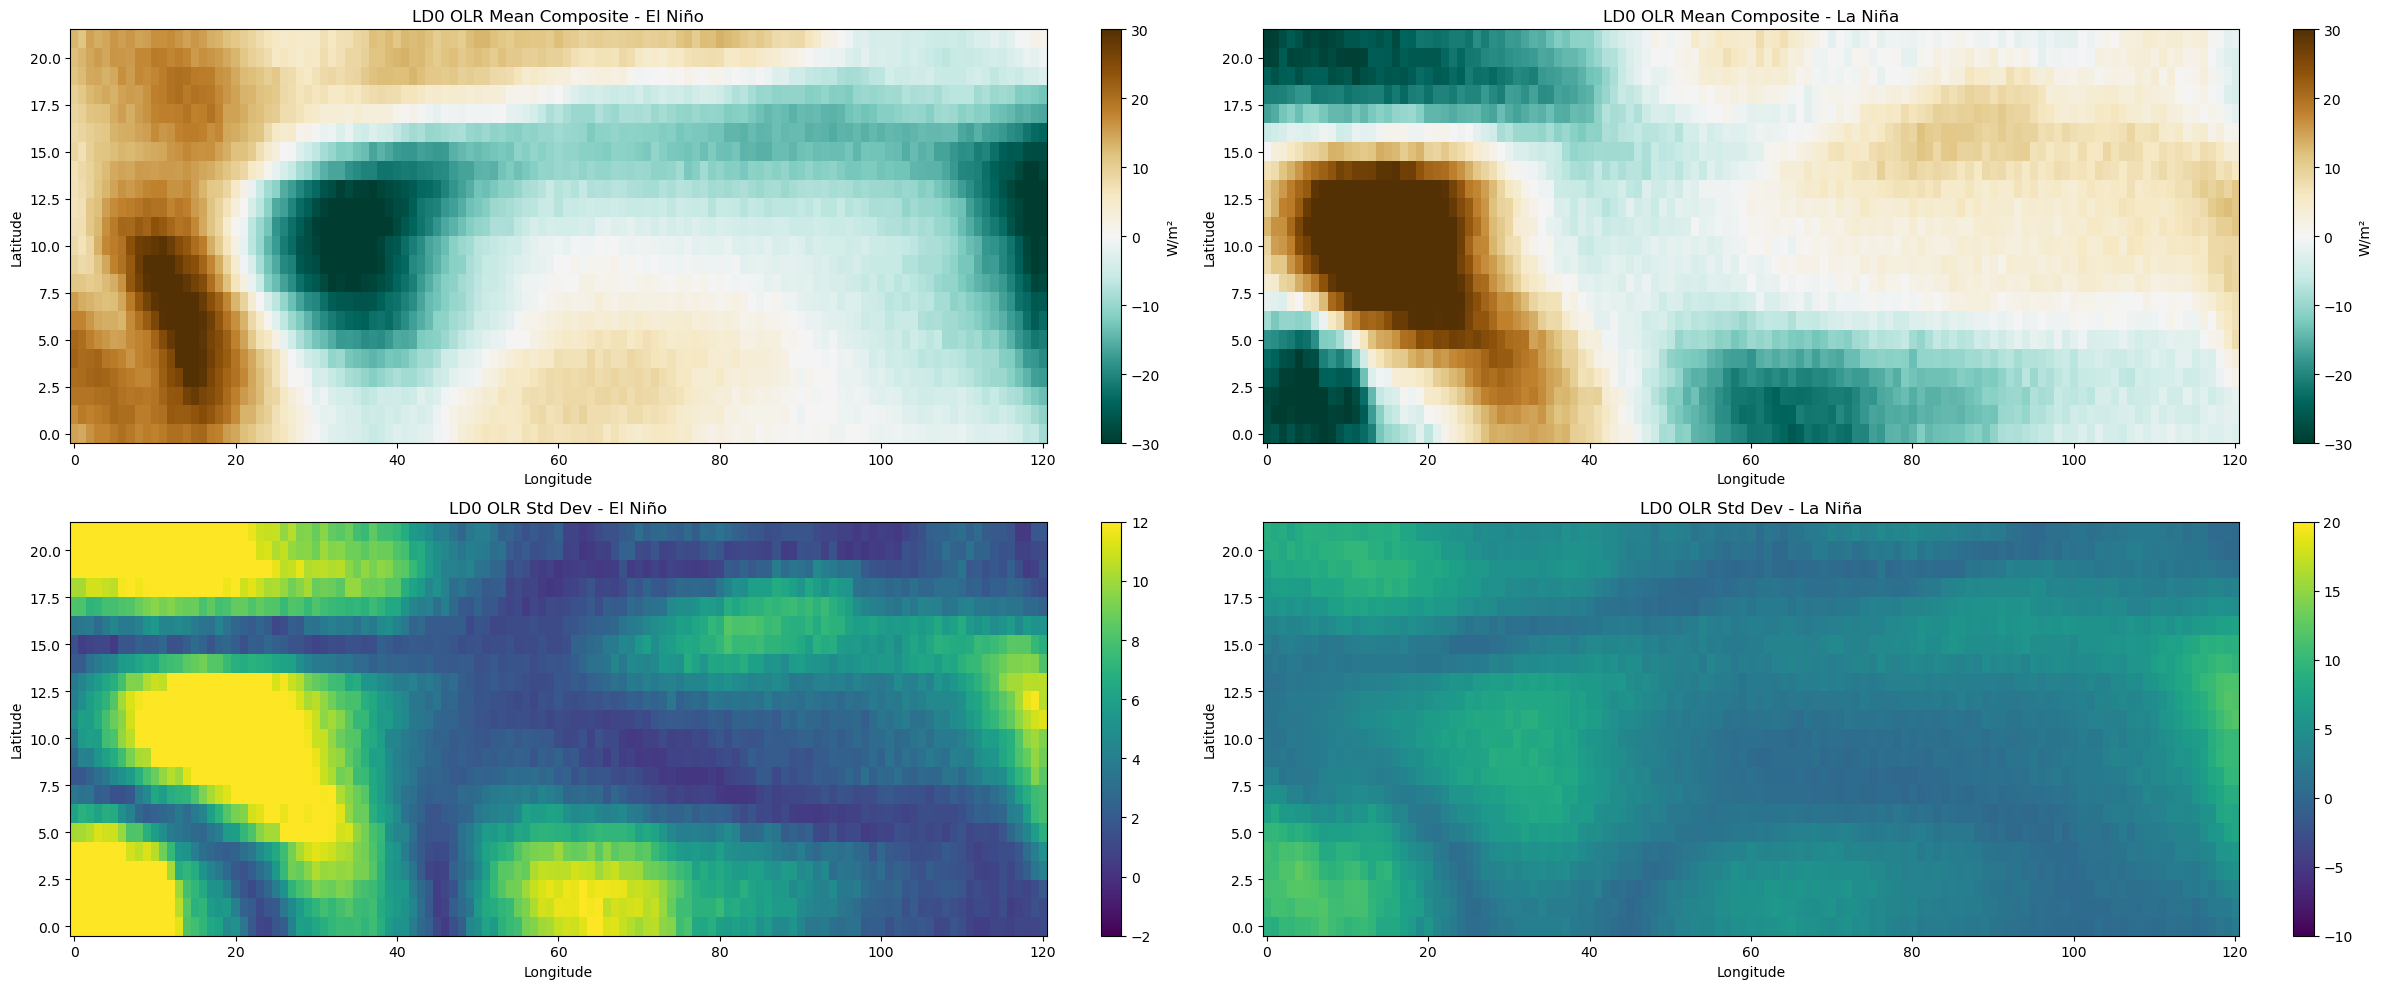

In [134]:
fig, axs = plt.subplots(2, 2, figsize=(24, 10))
cmap_mean_olr = 'BrBG_r'
cmap_std = 'viridis'

# Mean Composite - El Niño
im1 = axs[0, 0].imshow(olr_nino_mean, cmap=cmap_mean_olr, origin='lower', aspect='auto', vmin = -30, vmax = 30)
axs[0, 0].set_title('LD0 OLR Mean Composite - El Niño')
cbar1 = fig.colorbar(im1, ax=axs[0, 0], fraction=0.046)
cbar1.set_label('W/m²')

# Mean Composite - La Niña
im2 = axs[0, 1].imshow(olr_nina_mean, cmap=cmap_mean_olr, origin='lower', aspect='auto', vmin = -30, vmax = 30)
axs[0, 1].set_title('LD0 OLR Mean Composite - La Niña')
cbar2 = fig.colorbar(im2, ax=axs[0, 1], fraction=0.046)
cbar2.set_label('W/m²')

# Std Dev - El Niño
im3 = axs[1, 0].imshow(olr_nino_std, cmap=cmap_std, origin='lower', aspect='auto', vmin = -2, vmax = 12)
axs[1, 0].set_title('LD0 OLR Std Dev - El Niño')
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

# Std Dev - La Niña
im4 = axs[1, 1].imshow(olr_nina_std, cmap=cmap_std, origin='lower', aspect='auto', vmin = -10, vmax = 20)
axs[1, 1].set_title('LD0 OLR Std Dev - La Niña')
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

# Adjust layout and save
for ax in axs.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
#plt.savefig('ld0_sst_composites_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

## memmap stuff for n_realizations

In [184]:
z_samples = []

In [185]:
batch_size = 50
n_realizations = 1000
n_samples = 6000

In [186]:
n_batches = (n_realizations + batch_size -1) // batch_size

In [187]:
n_batches

20

In [188]:
import numpy as np
import os

save_path = 'z_samples_0703.npy'
if os.path.exists(save_path):
    os.remove(save_path)

In [190]:
# create memmap array on disk
z_samples_memmap = np.memmap(save_path, dtype='float32', mode='w+', shape=(n_samples, latent_dim, n_realizations))

# loop with incremental writes
for b in range(n_batches):
    current_batch_size = min(batch_size, n_realizations - b * batch_size)
    epsilon = np.random.randn(n_samples, latent_dim, current_batch_size)
    
    # to ensure no broadcast error from difference in shapes!
    zsampling_expanded = np.expand_dims(z_sampling, -1)

    # add small noise to increase variability and address small std
    noise = np.random.normal(loc=0.0, scale=0.1, size=zsampling_expanded.shape)
    zsampling_expanded += noise

    # write directly to file-backed array for particular batch
    z_samples_memmap[:, :, b*batch_size:b*batch_size + current_batch_size] = zsampling_expanded

# Flush to disk
z_samples_memmap.flush()
print("Saved z_samples with shape:", z_samples_memmap.shape)

Saved z_samples with shape: (6000, 20, 1000)


In [191]:
z_samples_memmap.shape

(6000, 20, 1000)

In [192]:
z_samples_memmap

memmap([[[-6.00463413e-02, -6.00463413e-02, -6.00463413e-02, ...,
          -1.23617856e-03, -1.23617856e-03, -1.23617856e-03],
         [ 1.39901742e-01,  1.39901742e-01,  1.39901742e-01, ...,
           1.18360475e-01,  1.18360475e-01,  1.18360475e-01],
         [ 1.05126035e+00,  1.05126035e+00,  1.05126035e+00, ...,
           1.03713465e+00,  1.03713465e+00,  1.03713465e+00],
         ...,
         [ 8.37077871e-02,  8.37077871e-02,  8.37077871e-02, ...,
           7.52426684e-01,  7.52426684e-01,  7.52426684e-01],
         [-1.47454441e+00, -1.47454441e+00, -1.47454441e+00, ...,
          -2.48085275e-01, -2.48085275e-01, -2.48085275e-01],
         [ 7.05682814e-01,  7.05682814e-01,  7.05682814e-01, ...,
           6.64670944e-01,  6.64670944e-01,  6.64670944e-01]],

        [[-8.51338506e-01, -8.51338506e-01, -8.51338506e-01, ...,
          -6.81041002e-01, -6.81041002e-01, -6.81041002e-01],
         [-6.00114942e-01, -6.00114942e-01, -6.00114942e-01, ...,
          -1.95537046e